In [1]:
# imports

import pandas as pd
import numpy as np
import mlflow.sklearn

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv("reddit_preprocessed.csv")
df.head()

,clean_comment,category,words,stop_words,characters,punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [6]:
import mlflow

mlflow.set_tracking_uri("http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/")

In [7]:
mlflow.set_experiment("Max Features - Comparison")


<Experiment: artifact_location='s3://mlflow-bucket-078/150696966607405312', creation_time=1758657773025, experiment_id='150696966607405312', last_update_time=1758657773025, lifecycle_stage='active', name='Max Features - Comparison', tags={}>

In [10]:
# based on the previous experiments, we are going to use tfidf with bigrams configuration.

def run_experiment_max_features(max_feature, df, feature_column, target_column):

    ngram_range = (1,2)
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=max_feature)
    vec_name = "TfidfVectorizer"

    X_train, X_test, y_train, y_test = train_test_split(df[feature_column], df[target_column], test_size=0.2, random_state=0)

    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test) # correct way to do it, without data leakage
    
    with mlflow.start_run() as run:
        
        # Experiments tags
        mlflow.set_tag("mlflow.runName", f"TFIDF_bigrams_max_features_{max_feature}")
        mlflow.set_tag("experiment_type", "max_feature_comparison")
        mlflow.set_tag("model_type", "RandomForestClassifier")
        mlflow.set_tag("Description", "Experiment to compare the different possible max_features")

        # parameters for vectorizer and model
        mlflow.log_param("vectorizer_type", vec_name)
        mlflow.log_param("vectorizer_maxfeatures", max_feature)
        mlflow.log_param("vectorizer_ngramrange", ngram_range)

        mlflow.log_param("n_estimators", 200)
        mlflow.log_param("max_depth", 15)

        comparison_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=0)
        comparison_model.fit(X_train, y_train)
        predictions = comparison_model.predict(X_test)

        comparison_accuracy = accuracy_score(y_test, predictions)

        mlflow.log_metric("accuracy", comparison_accuracy)

        classification_rep = classification_report(y_test, predictions, output_dict=True)

        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
                for metric, value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric}", value)

        class_names = [-1,0,1]

        # Confusion matrix plot
        conf_matrix = confusion_matrix(y_test, predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - max_features = {max_feature}")

        # Save and log the confusion matrix plot
        plt.savefig(f"conf_matrices/confusion_matrix_max_features_{max_feature}.png")
        mlflow.log_artifact(f"conf_matrices/confusion_matrix_max_features_{max_feature}.png")

        mlflow.sklearn.log_model(comparison_model, f"random_forest_max_features_{max_feature}")

2025/09/23 17:31:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/23 17:31:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_bigrams_max_features_1000 at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312/runs/3148810658be48a3b6beaab22c9b1932
🧪 View experiment at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312


2025/09/23 17:31:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/23 17:32:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_bigrams_max_features_2000 at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312/runs/164fa5e16d5e41e297c6177782700142
🧪 View experiment at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312


2025/09/23 17:32:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/23 17:32:45 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


...

🏃 View run TFIDF_bigrams_max_features_8000 at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312/runs/8b6e4665a5254f9190404bb98e584715
🧪 View experiment at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312


2025/09/23 17:36:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/23 17:36:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_bigrams_max_features_9000 at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312/runs/5014aa0f6e854d2bb9c2866cd6fd6665
🧪 View experiment at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312


2025/09/23 17:37:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/23 17:37:21 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_bigrams_max_features_10000 at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312/runs/8c257932fd09427eb31689cd0c1284a7
🧪 View experiment at: http://ec2-18-118-21-121.us-east-2.compute.amazonaws.com:5000/#/experiments/150696966607405312


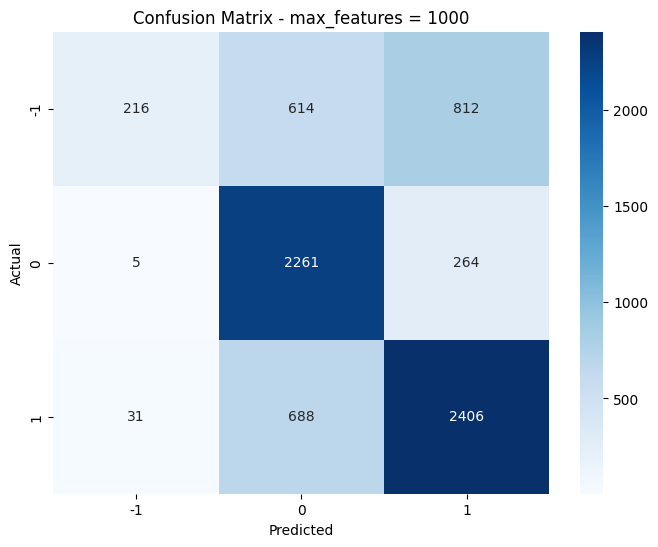

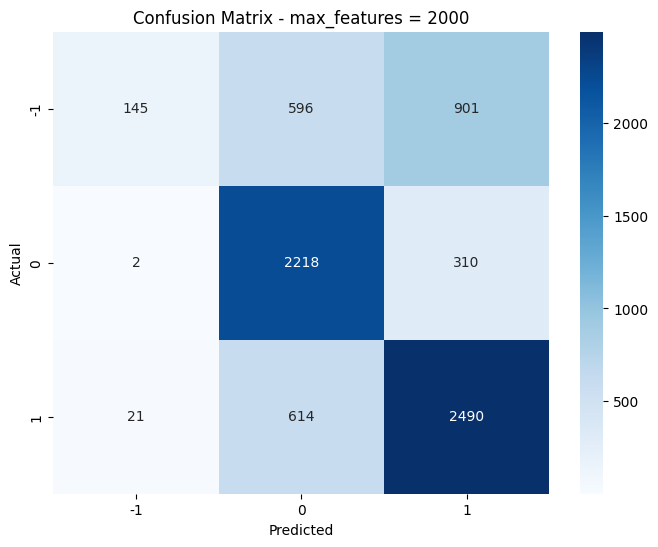

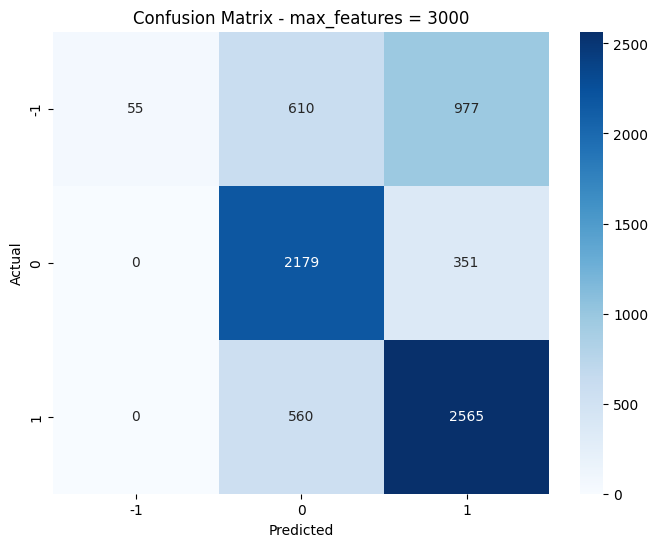

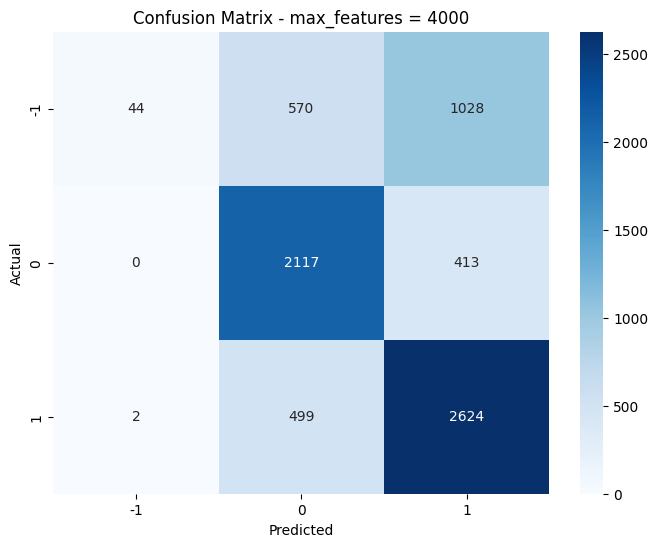

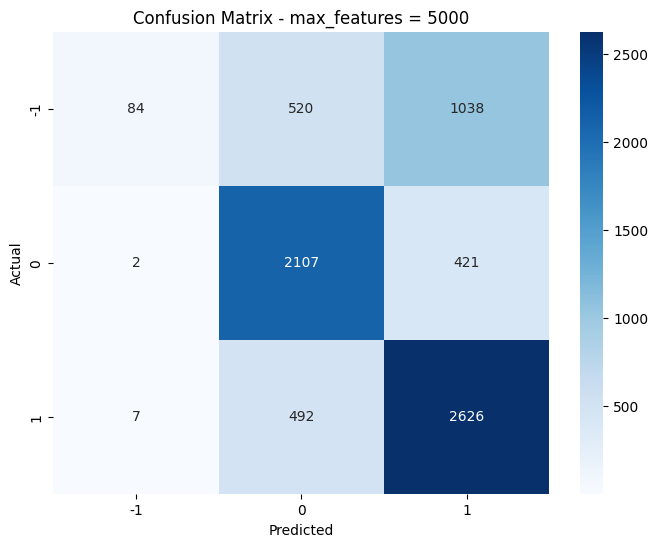

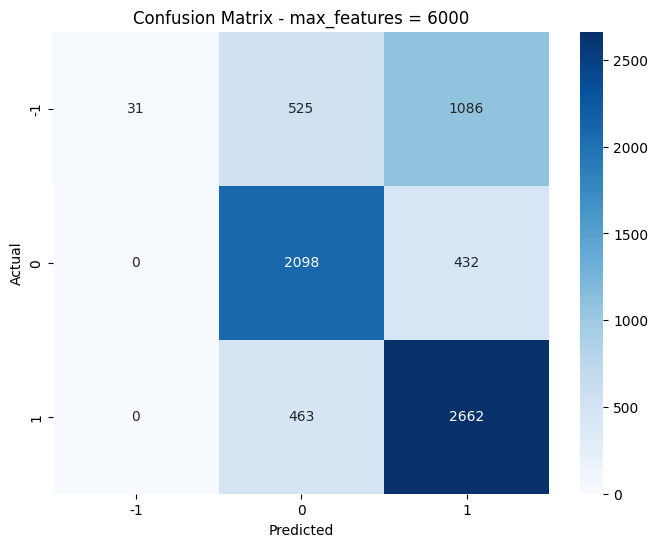

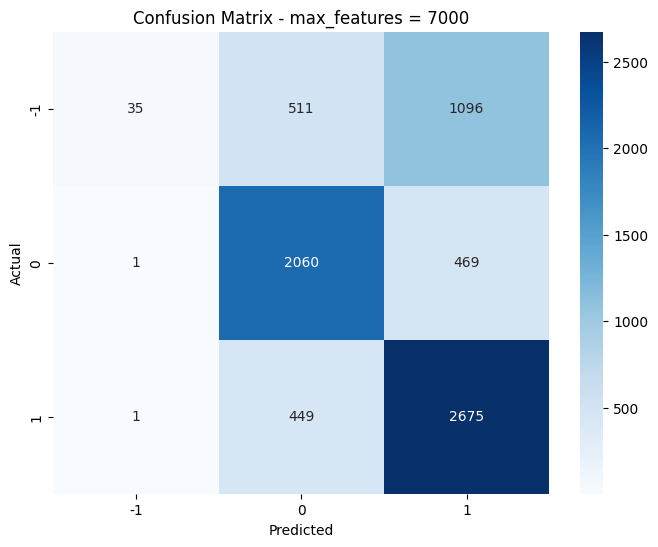

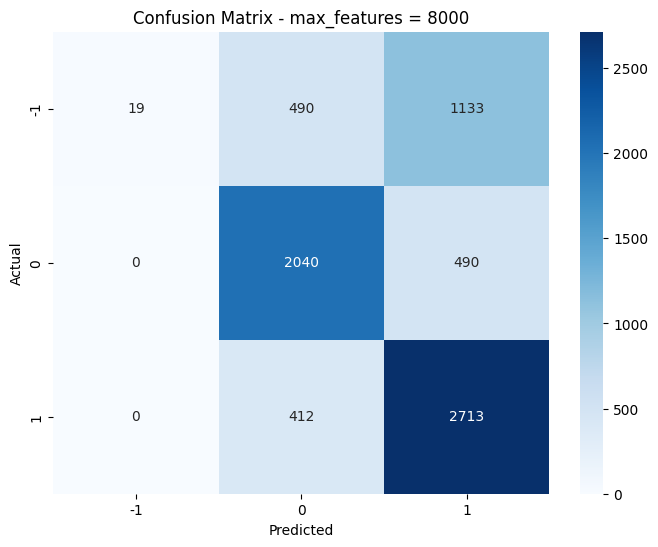

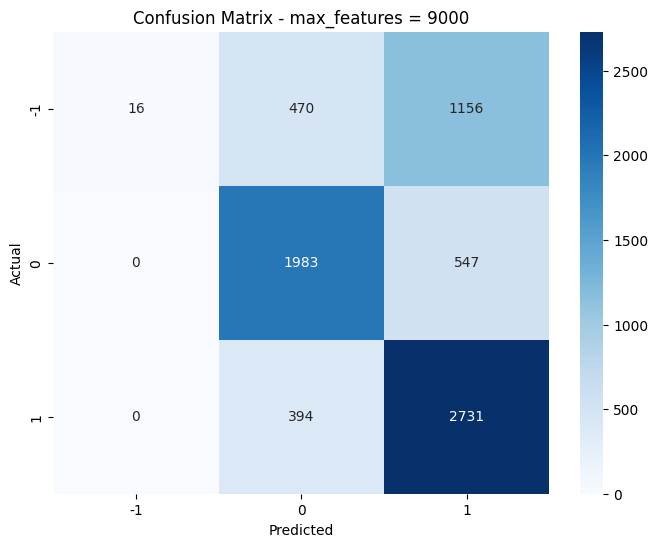

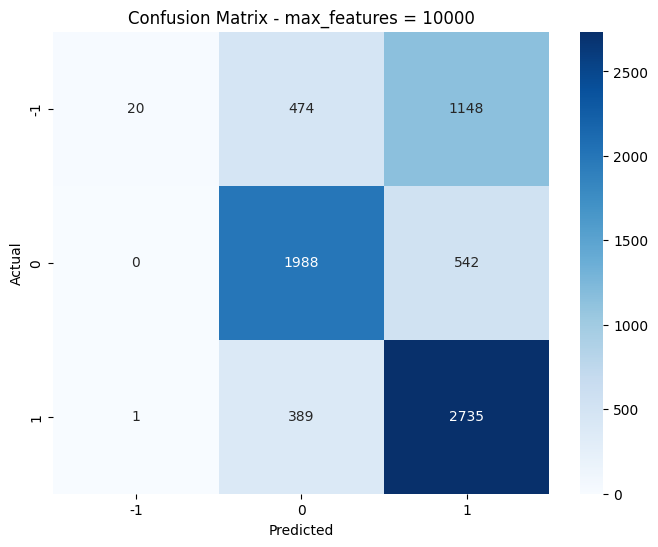

In [11]:
max_feature_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
for max_feature in max_feature_list: 
    run_experiment_max_features(max_feature, df=df, feature_column= 'clean_comment', target_column= 'category')

